In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
view_history = pd.read_excel("../Dataset/View_History.xlsx")
movie_crawling = pd.read_csv("../Movie_crawling/movie_crawling_temp (광일).csv")

In [3]:
view_history_merged = view_history.merge(movie_crawling, on="MOVIE_ID", how="left")
view_history_merged.head()

,USER_ID,MOVIE_ID,DURATION,WATCH_DAY,WATCH_SEQ,totCnt,MovieCd,MovieNm(csv),movieNm(api),showTm,prdtYear,openDt,typeNm,nationNm,genreNm,watchGrade
0,0,4243,1,20210314,1,27.0,NaN,코마,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,4243,111,20210314,2,27.0,NaN,코마,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,1860,101,20210319,1,1.0,20070178,이퀼리브리엄,이퀼리브리엄,107.0,2002.0,20031002.0,장편,미국,액션,15세관람가
3,0,2170,1,20210325,1,58.0,NaN,소울,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,6031,100,20210326,1,3.0,NaN,당신이잠든사이에,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> movie_crawling에서 정보를 찾지 못한 영화 (NaN) 집계

In [4]:
# movieNm(api)가 NaN인 행 = movie_crawling에서 매칭 실패한 영화
nan_movies = view_history_merged[view_history_merged["movieNm(api)"].isna()]

# MOVIE_ID별 집계: 영화명, 시청 유저수, 총 시청횟수, 총 시청시간
nan_summary = (
    nan_movies.groupby("MOVIE_ID")
    .agg(
        MovieNm          = ("MovieNm(csv)", "first"),
        totCnt           = ("totCnt", "first"),
        unique_users     = ("USER_ID", "nunique"),
        total_watch_cnt  = ("WATCH_SEQ", "count"),
        total_duration   = ("DURATION", "sum"),
    )
    .sort_values("total_watch_cnt", ascending=False)
    .reset_index()
)

print(f"NaN 영화 종류: {len(nan_summary)}개")
print(f"NaN 영화 관련 시청 기록: {len(nan_movies)}행 / 전체 {len(view_history_merged)}행 ({len(nan_movies)/len(view_history_merged)*100:.1f}%)")
display(nan_summary)

NaN 영화 종류: 2946개
NaN 영화 관련 시청 기록: 68026행 / 전체 106205행 (64.1%)


,MOVIE_ID,MovieNm,totCnt,unique_users,total_watch_cnt,total_duration
0,2170,소울,58.0,813,1873,43994
1,1616,마스터,160.0,972,1374,98950
2,1900,죽여주는여자,4.0,1079,1354,77687
3,5184,궁,232.0,1086,1345,93152
4,8579,겨울왕국2,2.0,561,1165,45435
...,...,...,...,...,...,...
2941,8839,감염지구최후의날,0.0,1,1,8
2942,11547,웃는남자,4.0,1,1,47
2943,2550,자객섭은낭,3.0,1,1,1
2944,11550,아웃브레이크지구최후의날,0.0,1,1,4


In [5]:
view_history_merged.to_excel("../Dataset/View_History_Merged.xlsx", index=False)
nan_summary.to_excel("../Dataset/NaN_Movie_Summary.xlsx", index=False)

> EDA: NaN 영화의 totCnt 분포

=== totCnt 분포 (NaN 영화 기준) ===
totCnt
0.0         934
1.0           1
2.0         512
3.0         274
4.0         190
5.0         138
6.0         110
7.0          74
8.0          54
9.0          50
10.0         39
11.0         24
12.0         24
13.0         20
14.0         19
15.0         23
16.0         27
17.0         16
18.0         20
19.0         21
20.0         11
21.0         13
22.0         17
23.0          5
24.0          5
25.0         10
26.0          7
27.0          6
28.0          4
29.0          6
30.0          5
31.0          5
32.0         10
33.0          6
34.0         10
35.0          4
36.0         12
37.0          5
38.0          1
39.0          1
40.0          1
41.0          7
42.0          2
43.0          3
44.0          4
46.0          2
47.0          6
49.0          1
50.0          2
51.0          2
52.0          2
53.0          2
54.0          1
55.0          2
56.0          3
57.0          3
58.0          3
59.0          1
60.0          5
61.0          1
62.

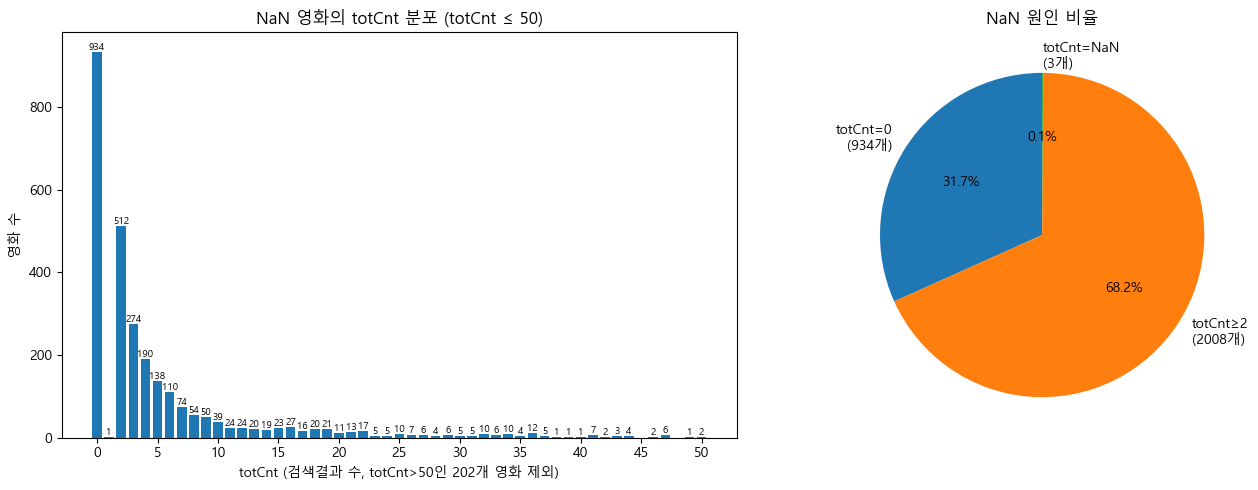


totCnt=0   (검색결과 없음):   934개 (31.7%)
totCnt≥2   (검색결과 중복):   2008개 (68.2%)
totCnt=NaN (API 오류):        3개 (0.1%)
totCnt>50  (극단 이상치): 202개


In [6]:
# totCnt 값별 영화 수 집계
totcnt_dist = nan_summary["totCnt"].value_counts().sort_index()

print("=== totCnt 분포 (NaN 영화 기준) ===")
print(totcnt_dist.to_string())
print(f"\ntotCnt 자체가 NaN인 영화 수 (API 오류): {nan_summary['totCnt'].isna().sum()}개")
print(f"totCnt 최댓값: {nan_summary['totCnt'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 이상치 제거 후 totCnt 분포 (CLIP 이하만 표시)
CLIP = 50
clipped = nan_summary["totCnt"].dropna()
clipped_dist = clipped[clipped <= CLIP].value_counts().sort_index()
over_clip = (clipped > CLIP).sum()

bars = axes[0].bar(clipped_dist.index, clipped_dist.values)
for bar in bars:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width() / 2, h, str(int(h)),
                     ha="center", va="bottom", fontsize=7)
axes[0].set_xlabel(f"totCnt (검색결과 수, totCnt>{CLIP}인 {over_clip}개 영화 제외)")
axes[0].set_ylabel("영화 수")
axes[0].set_title(f"NaN 영화의 totCnt 분포 (totCnt ≤ {CLIP})")
axes[0].set_xticks(range(0, CLIP + 1, 5))

# 오른쪽: NaN 원인 비율
cnt0      = (nan_summary["totCnt"] == 0).sum()
cnt_other = (nan_summary["totCnt"] > 1).sum()
cnt_nan   = nan_summary["totCnt"].isna().sum()

labels = [f"totCnt=0\n({cnt0}개)", f"totCnt≥2\n({cnt_other}개)", f"totCnt=NaN\n({cnt_nan}개)"]
axes[1].pie([cnt0, cnt_other, cnt_nan], labels=labels, autopct="%1.1f%%", startangle=90)
axes[1].set_title("NaN 원인 비율")

plt.tight_layout()
plt.show()

print(f"\ntotCnt=0   (검색결과 없음):   {cnt0}개 ({cnt0/len(nan_summary)*100:.1f}%)")
print(f"totCnt≥2   (검색결과 중복):   {cnt_other}개 ({cnt_other/len(nan_summary)*100:.1f}%)")
print(f"totCnt=NaN (API 오류):        {cnt_nan}개 ({cnt_nan/len(nan_summary)*100:.1f}%)")
print(f"totCnt>{CLIP}  (극단 이상치): {over_clip}개")

> Section 1: 장르 / 국가 / 관람등급 분포 (정보 있는 영화만)(신뢰불가능)

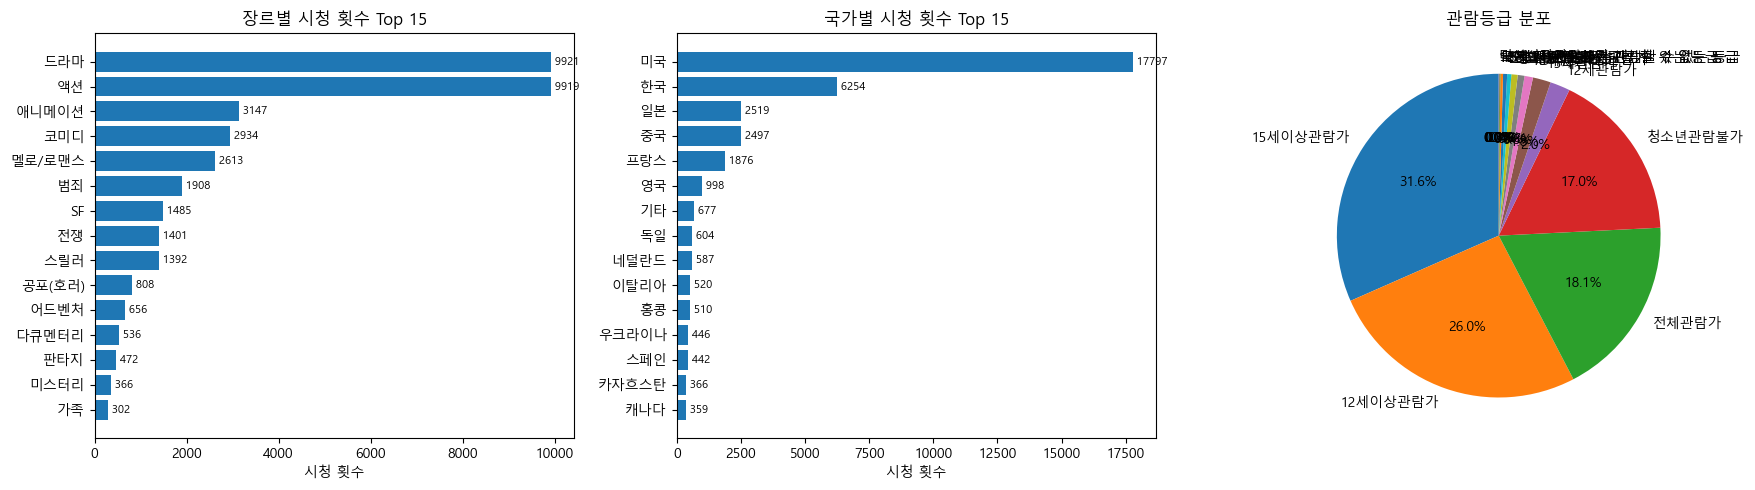

In [7]:
valid = view_history_merged.dropna(subset=["movieNm(api)"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 장르별 시청 횟수 Top 15
genre_cnt = valid["genreNm"].value_counts().head(15)
axes[0].barh(genre_cnt.index[::-1], genre_cnt.values[::-1])
for i, v in enumerate(genre_cnt.values[::-1]):
    axes[0].text(v, i, f" {v}", va="center", fontsize=8)
axes[0].set_title("장르별 시청 횟수 Top 15")
axes[0].set_xlabel("시청 횟수")

# 국가별 시청 횟수 Top 15
nation_cnt = valid["nationNm"].value_counts().head(15)
axes[1].barh(nation_cnt.index[::-1], nation_cnt.values[::-1])
for i, v in enumerate(nation_cnt.values[::-1]):
    axes[1].text(v, i, f" {v}", va="center", fontsize=8)
axes[1].set_title("국가별 시청 횟수 Top 15")
axes[1].set_xlabel("시청 횟수")

# 관람등급 분포
grade_cnt = valid["watchGrade"].value_counts()
axes[2].pie(grade_cnt.values, labels=grade_cnt.index, autopct="%1.1f%%", startangle=90)
axes[2].set_title("관람등급 분포")

plt.tight_layout()
plt.show()

> Section 2: 영화 완주율 분석 (DURATION vs showTm) (신뢰불가능)

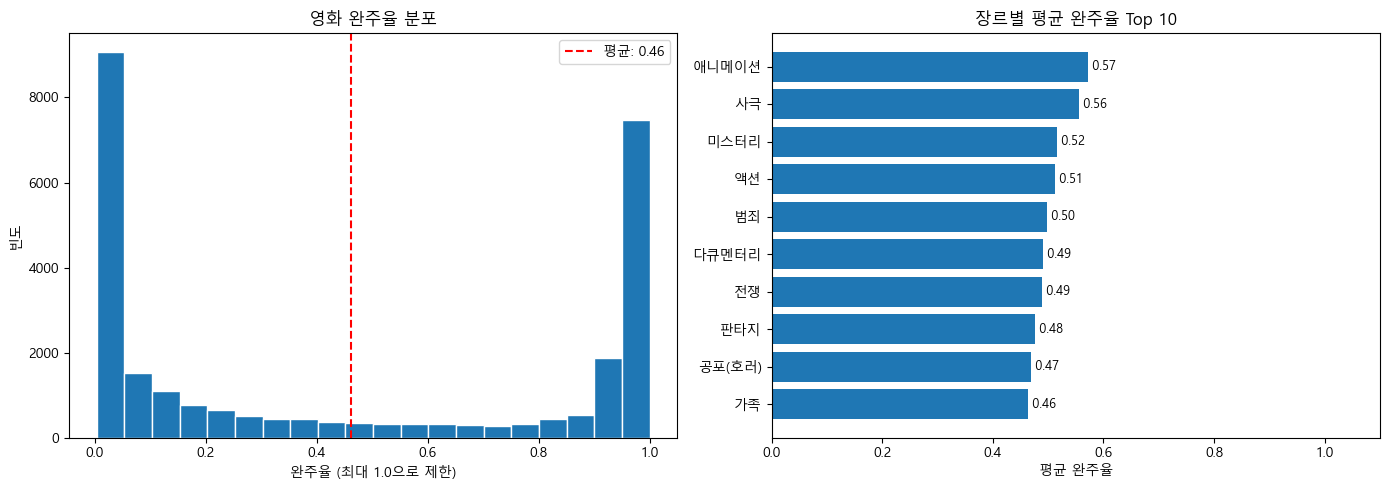

전체 평균 완주율: 46.16%
완주한 시청 건수 (완주율=1.0): 4727건 (17.3%)


In [8]:
# 유저-영화 쌍별 총 시청시간 합산 후 showTm과 비교
completion = (
    valid.groupby(["USER_ID", "MOVIE_ID", "showTm", "genreNm"])["DURATION"]
    .sum()
    .reset_index()
)
completion = completion[completion["showTm"] > 0]
completion["completion_rate"] = (completion["DURATION"] / completion["showTm"]).clip(upper=1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 완주율 분포
axes[0].hist(completion["completion_rate"], bins=20, edgecolor="white")
axes[0].set_xlabel("완주율 (최대 1.0으로 제한)")
axes[0].set_ylabel("빈도")
axes[0].set_title("영화 완주율 분포")
mean_cr = completion["completion_rate"].mean()
axes[0].axvline(mean_cr, color="red", linestyle="--", label=f"평균: {mean_cr:.2f}")
axes[0].legend()

# 장르별 평균 완주율 Top 10
genre_completion = (
    completion.groupby("genreNm")["completion_rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
axes[1].barh(genre_completion.index[::-1], genre_completion.values[::-1])
for i, v in enumerate(genre_completion.values[::-1]):
    axes[1].text(v, i, f" {v:.2f}", va="center", fontsize=9)
axes[1].set_xlabel("평균 완주율")
axes[1].set_title("장르별 평균 완주율 Top 10")
axes[1].set_xlim(0, 1.1)

plt.tight_layout()
plt.show()

print(f"전체 평균 완주율: {mean_cr:.2%}")
print(f"완주한 시청 건수 (완주율=1.0): {(completion['completion_rate']==1.0).sum()}건 ({(completion['completion_rate']==1.0).mean()*100:.1f}%)")

> Section 3: 영화 제작연도 분석 (신뢰불가능)

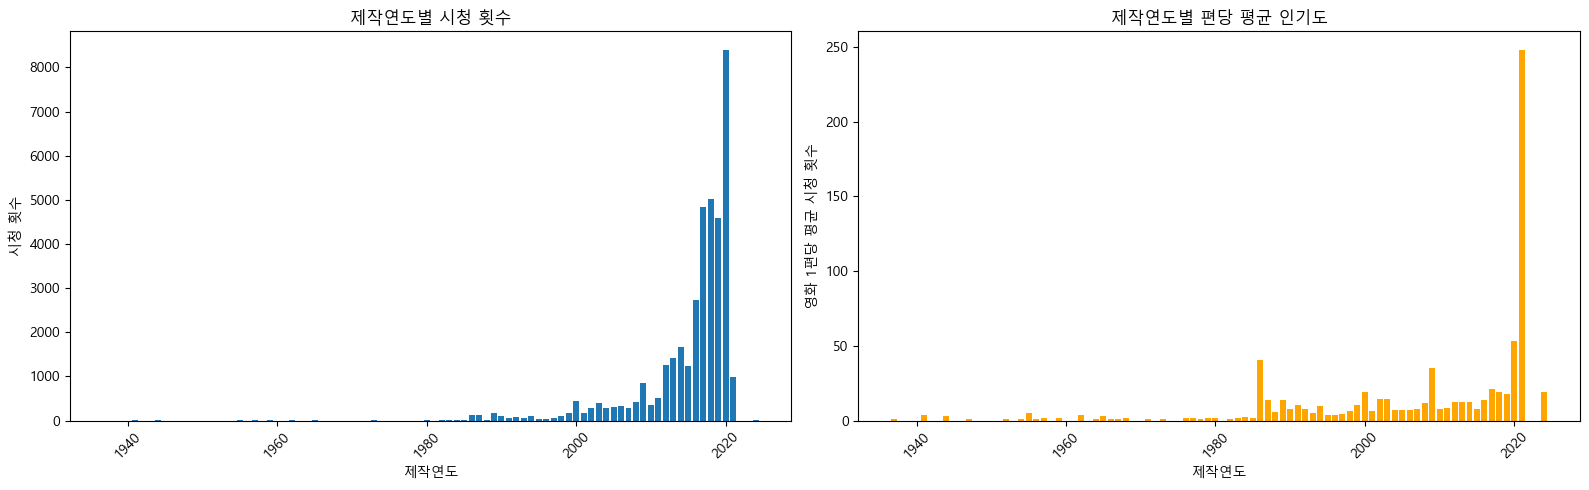

 prdtYear  watch_count  total_duration  unique_movies  avg_watch_per_movie
     2020         8398          317973            157            53.490446
     2018         5010          206339            259            19.343629
     2017         4845          191102            228            21.250000
     2019         4594          162219            261            17.601533
     2016         2723          100272            195            13.964103
     2014         1673           71538            137            12.211679
     2013         1417           66313            116            12.215517
     2012         1260           59564            102            12.352941
     2015         1239           53465            159             7.792453
     2021          992           67827              4           248.000000


In [9]:
year_data = valid.dropna(subset=["prdtYear"]).copy()
year_data["prdtYear"] = year_data["prdtYear"].astype(int)

year_watch = year_data.groupby("prdtYear").agg(
    watch_count    = ("MOVIE_ID", "count"),
    total_duration = ("DURATION", "sum"),
    unique_movies  = ("MOVIE_ID", "nunique"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 제작연도별 시청 횟수
axes[0].bar(year_watch["prdtYear"], year_watch["watch_count"])
axes[0].set_xlabel("제작연도")
axes[0].set_ylabel("시청 횟수")
axes[0].set_title("제작연도별 시청 횟수")
axes[0].tick_params(axis="x", rotation=45)

# 제작연도별 영화 1편당 평균 시청 횟수 (인기 효율)
year_watch["avg_watch_per_movie"] = year_watch["watch_count"] / year_watch["unique_movies"]
axes[1].bar(year_watch["prdtYear"], year_watch["avg_watch_per_movie"], color="orange")
axes[1].set_xlabel("제작연도")
axes[1].set_ylabel("영화 1편당 평균 시청 횟수")
axes[1].set_title("제작연도별 편당 평균 인기도")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(year_watch.sort_values("watch_count", ascending=False).head(10).to_string(index=False))

> Section 4: 시청 요일 패턴 분석 (요일별 / 날짜별 추이) (신뢰가능)

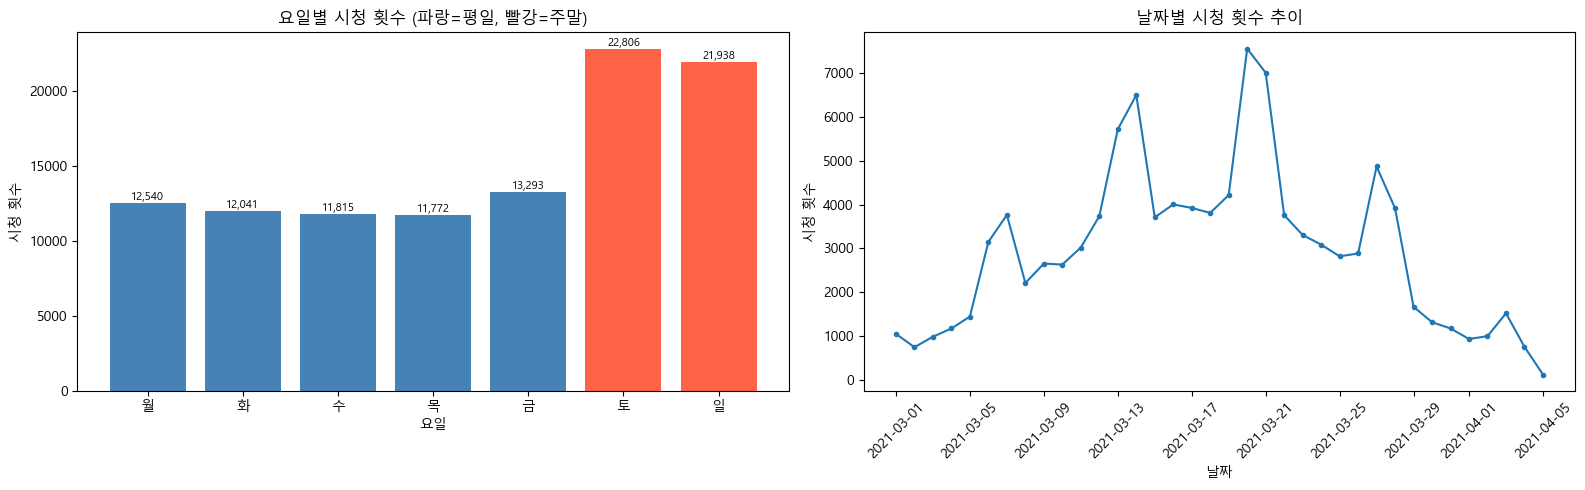

평일 합계: 61,461  |  주말 합계: 44,744  |  주말 비율: 42.1%


In [10]:
watch_day = view_history_merged.copy()
watch_day["WATCH_DATE"] = pd.to_datetime(watch_day["WATCH_DAY"], format="%Y%m%d")
watch_day["day_of_week"] = watch_day["WATCH_DATE"].dt.day_name()

dow_order  = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_labels = ["월", "화", "수", "목", "금", "토", "일"]
dow_cnt = watch_day.groupby("day_of_week")["MOVIE_ID"].count().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 요일별 시청 횟수 (주말=빨강)
bars = axes[0].bar(dow_labels, dow_cnt.values,
                   color=["steelblue" if d not in ["Saturday","Sunday"] else "tomato" for d in dow_order])
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h, f"{h:,}", ha="center", va="bottom", fontsize=8)
axes[0].set_xlabel("요일")
axes[0].set_ylabel("시청 횟수")
axes[0].set_title("요일별 시청 횟수 (파랑=평일, 빨강=주말)")

# 날짜별 시청 추이
daily_cnt = watch_day.groupby("WATCH_DATE")["MOVIE_ID"].count()
axes[1].plot(daily_cnt.index, daily_cnt.values, marker="o", markersize=3)
axes[1].set_xlabel("날짜")
axes[1].set_ylabel("시청 횟수")
axes[1].set_title("날짜별 시청 횟수 추이")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

weekday = dow_cnt[["Monday","Tuesday","Wednesday","Thursday","Friday"]].sum()
weekend = dow_cnt[["Saturday","Sunday"]].sum()
print(f"평일 합계: {weekday:,}  |  주말 합계: {weekend:,}  |  주말 비율: {weekend/(weekday+weekend)*100:.1f}%")

> Section 5: 유저 행동 세분화 (3번째 장르 다양성만은 신뢰 불가능)

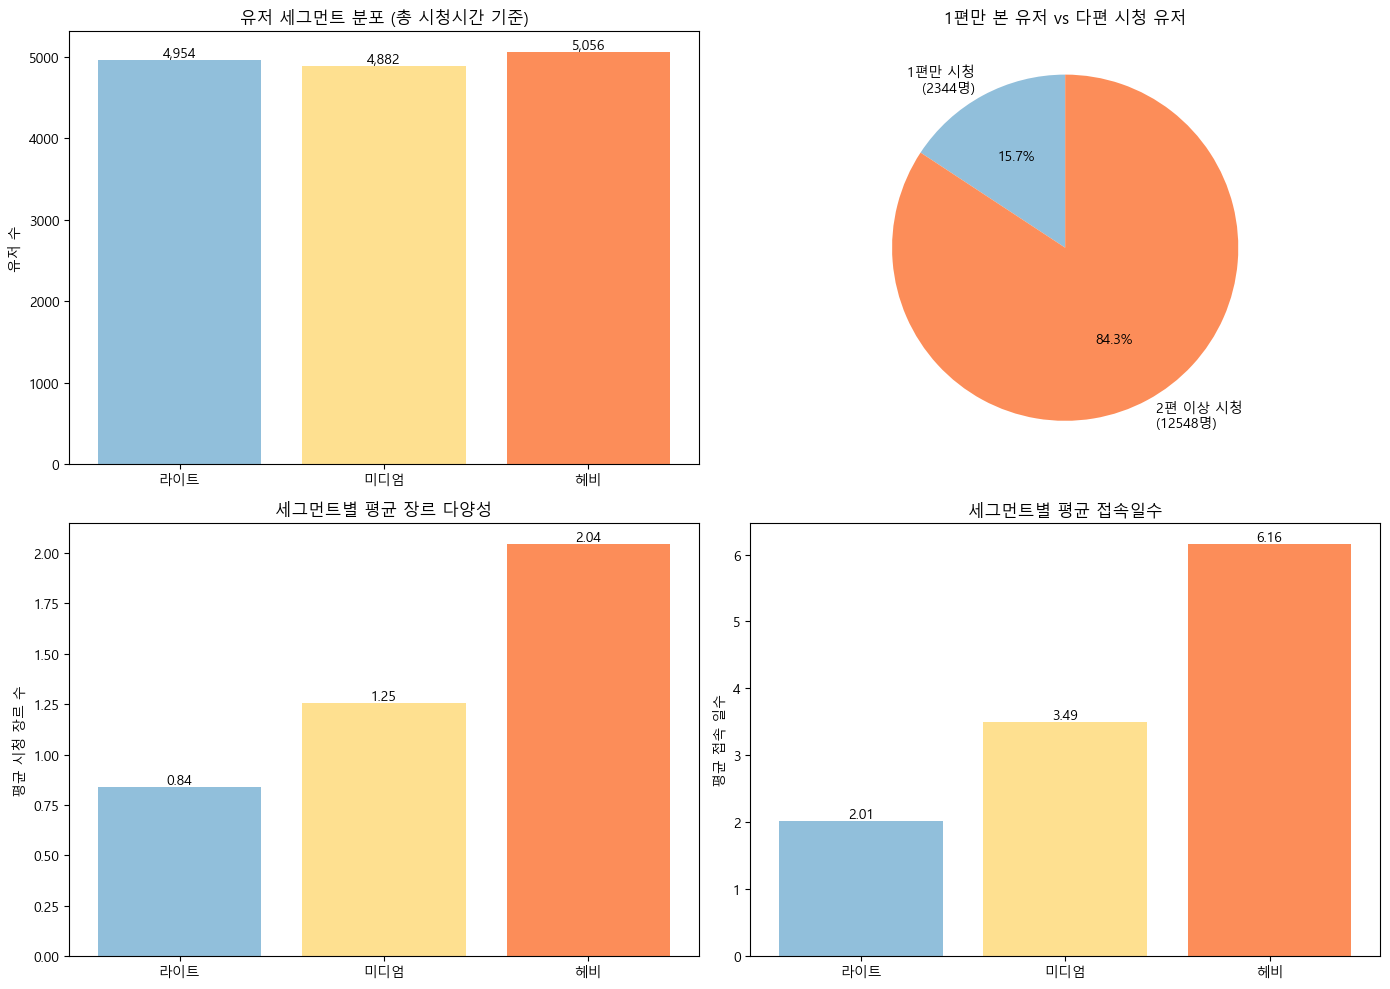

라이트 (≤127분): 4,954명
미디엄 (127~345분): 4,882명
헤비 (>345분): 5,056명


In [11]:
user_stats = view_history_merged.groupby("USER_ID").agg(
    total_duration  = ("DURATION", "sum"),
    unique_movies   = ("MOVIE_ID", "nunique"),
    unique_days     = ("WATCH_DAY", "nunique"),
    unique_genres   = ("genreNm", "nunique"),
).reset_index()

# 총 시청시간 기준 33/66 백분위수로 라이트/미디엄/헤비 분류
p33 = user_stats["total_duration"].quantile(0.33)
p66 = user_stats["total_duration"].quantile(0.66)
def segment(d):
    if d <= p33: return "라이트"
    elif d <= p66: return "미디엄"
    else: return "헤비"
user_stats["segment"] = user_stats["total_duration"].apply(segment)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 유저 세그먼트 분포
seg_cnt = user_stats["segment"].value_counts().reindex(["라이트","미디엄","헤비"])
axes[0,0].bar(seg_cnt.index, seg_cnt.values, color=["#91bfdb","#fee090","#fc8d59"])
for bar in axes[0,0].patches:
    h = bar.get_height()
    axes[0,0].text(bar.get_x()+bar.get_width()/2, h, f"{int(h):,}", ha="center", va="bottom")
axes[0,0].set_title("유저 세그먼트 분포 (총 시청시간 기준)")
axes[0,0].set_ylabel("유저 수")

# 2. 1편만 본 유저 vs 다편 유저
single = (user_stats["unique_movies"] == 1).sum()
multi  = (user_stats["unique_movies"] > 1).sum()
axes[0,1].pie([single, multi], labels=[f"1편만 시청\n({single}명)", f"2편 이상 시청\n({multi}명)"],
              autopct="%1.1f%%", startangle=90, colors=["#91bfdb","#fc8d59"])
axes[0,1].set_title("1편만 본 유저 vs 다편 시청 유저")

# 3. 세그먼트별 장르 다양성
genre_div = user_stats.groupby("segment")["unique_genres"].mean().reindex(["라이트","미디엄","헤비"])
axes[1,0].bar(genre_div.index, genre_div.values, color=["#91bfdb","#fee090","#fc8d59"])
for bar in axes[1,0].patches:
    h = bar.get_height()
    axes[1,0].text(bar.get_x()+bar.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom")
axes[1,0].set_title("세그먼트별 평균 장르 다양성")
axes[1,0].set_ylabel("평균 시청 장르 수")

# 4. 세그먼트별 평균 접속일수
day_div = user_stats.groupby("segment")["unique_days"].mean().reindex(["라이트","미디엄","헤비"])
axes[1,1].bar(day_div.index, day_div.values, color=["#91bfdb","#fee090","#fc8d59"])
for bar in axes[1,1].patches:
    h = bar.get_height()
    axes[1,1].text(bar.get_x()+bar.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom")
axes[1,1].set_title("세그먼트별 평균 접속일수")
axes[1,1].set_ylabel("평균 접속 일수")

plt.tight_layout()
plt.show()

print(f"라이트 (≤{p33:.0f}분): {seg_cnt['라이트']:,}명")
print(f"미디엄 ({p33:.0f}~{p66:.0f}분): {seg_cnt['미디엄']:,}명")
print(f"헤비 (>{p66:.0f}분): {seg_cnt['헤비']:,}명")

> Section 6: NaN 영화 추가 분석 — 유저별 NaN 비율 & totCnt vs 인기도

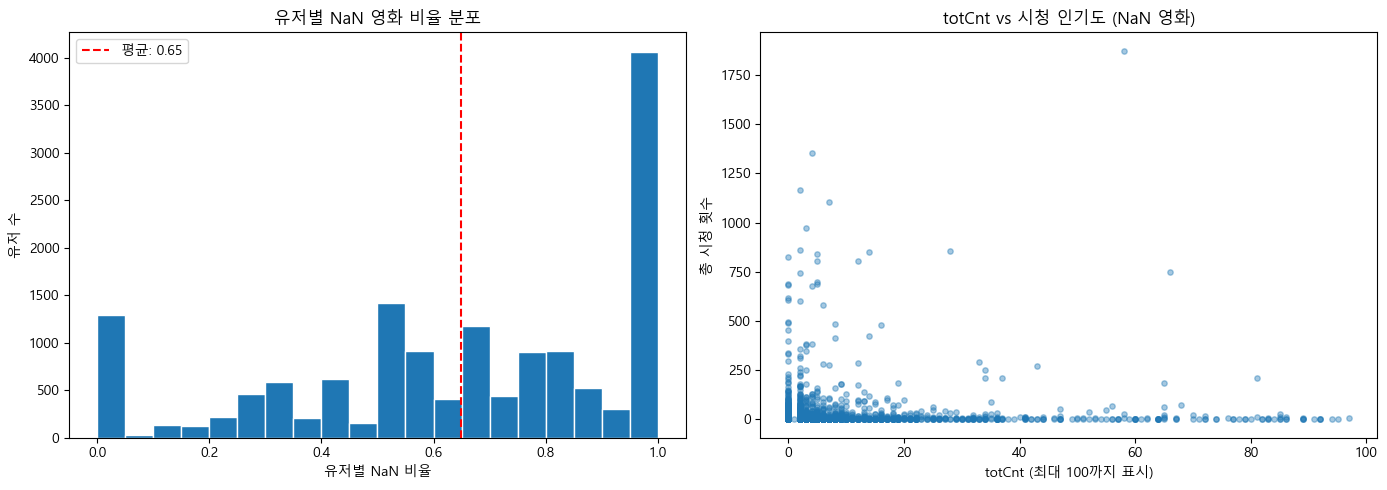

시청 기록이 전부 NaN 영화인 유저: 4055명 (27.2%)
유저별 평균 NaN 비율: 64.83%


In [12]:
# 유저별 NaN 비율: 시청 기록 중 NaN 영화가 차지하는 비율
user_nan = view_history_merged.groupby("USER_ID").agg(
    total_records = ("MOVIE_ID", "count"),
    nan_records   = ("movieNm(api)", lambda x: x.isna().sum()),
).reset_index()
user_nan["nan_ratio"] = user_nan["nan_records"] / user_nan["total_records"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 유저별 NaN 비율 분포
axes[0].hist(user_nan["nan_ratio"], bins=20, edgecolor="white")
axes[0].set_xlabel("유저별 NaN 비율")
axes[0].set_ylabel("유저 수")
axes[0].set_title("유저별 NaN 영화 비율 분포")
mean_nan = user_nan["nan_ratio"].mean()
axes[0].axvline(mean_nan, color="red", linestyle="--", label=f"평균: {mean_nan:.2f}")
axes[0].legend()

# totCnt vs 시청 인기도 (totCnt ≤ 100만 표시)
scatter_data = nan_summary[nan_summary["totCnt"].notna() & (nan_summary["totCnt"] <= 100)]
axes[1].scatter(scatter_data["totCnt"], scatter_data["total_watch_cnt"], alpha=0.4, s=15)
axes[1].set_xlabel("totCnt (최대 100까지 표시)")
axes[1].set_ylabel("총 시청 횟수")
axes[1].set_title("totCnt vs 시청 인기도 (NaN 영화)")

plt.tight_layout()
plt.show()

full_nan_users = (user_nan["nan_ratio"] == 1.0).sum()
print(f"시청 기록이 전부 NaN 영화인 유저: {full_nan_users}명 ({full_nan_users/len(user_nan)*100:.1f}%)")
print(f"유저별 평균 NaN 비율: {mean_nan:.2%}")